# Q-Learning – Learner Notebook

## Reinforcement Learning Lab

### Learning Objectives

By the end of this notebook, you will be able to:

- Explain the basic idea of Q-Learning.
- Identify the state space, action space, reward and Q-table of an environment.
- Implement an epsilon-greedy action-selection policy.
- Update Q-values using the Q-Learning update rule.
- Train an agent in the FrozenLake environment.
- Evaluate the learned policy.
- Visualize and interpret the learned Q-table and the agent's path.

> **Learner focus:** Complete the marked learner activities before running the corresponding solution cells.


## Before You Start

Q-Learning is a **model-free reinforcement learning algorithm**. The agent learns the value of taking an action in a state by interacting directly with the environment.

The learner does not need to know the transition model of the environment in advance. Instead, it repeatedly:

1. observes the current state,
2. selects an action,
3. receives a reward and the next state,
4. updates the Q-value,
5. continues until the episode ends.

In this notebook, we use **FrozenLake** as a small grid-world environment so that the learning process can be inspected easily.


## 1. Install and Import Dependencies

We use `gymnasium` for the reinforcement learning environment, NumPy for the Q-table, and Matplotlib for simple visualization.


In [1]:
!pip -q install gymnasium

import numpy as np
import random
import matplotlib.pyplot as plt
import gymnasium as gym

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Create the FrozenLake Environment

FrozenLake is a grid-world problem.

The standard 4 × 4 map contains:

- **S** – Start
- **F** – Frozen surface
- **H** – Hole
- **G** – Goal

The agent must move from the starting position to the goal without falling into a hole.

We initially use `is_slippery=False` so that the effect of Q-Learning is easier to understand.


In [2]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

print("Environment created successfully.")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)


Environment created successfully.
Observation space: Discrete(16)
Action space: Discrete(4)


## 3. Understand the Environment

The environment provides two important spaces:

### Observation Space

The observation represents the current **state** of the agent.

For the 4 × 4 FrozenLake environment, there are 16 possible states.

### Action Space

The agent can perform four actions:

- **0** – Move Left
- **1** – Move Down
- **2** – Move Right
- **3** – Move Up

### Learner Activity 1

Run the next cell and answer:

1. How many states are present?
2. How many actions can the agent perform?
3. What does one state represent in this environment?


In [3]:
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

action_names = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

print("\nActions:")
for action, name in action_names.items():
    print(action, "->", name)


Number of states: 16
Number of actions: 4

Actions:
0 -> Left
1 -> Down
2 -> Right
3 -> Up


## 4. Inspect a Single Interaction

An episode begins by resetting the environment.

The agent then selects an action. The environment returns:

- the next state,
- the reward,
- whether the episode has terminated,
- whether the episode has been truncated,
- additional information.

This interaction is the basis of reinforcement learning.


In [4]:
state, info = env.reset(seed=42)

print("Initial state:", state)

action = env.action_space.sample()
next_state, reward, terminated, truncated, info = env.step(action)

print("Action:", action_names[action])
print("Next state:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)


Initial state: 0
Action: Down
Next state: 4
Reward: 0
Terminated: False
Truncated: False


## 5. The Q-Table

Q-Learning stores what the agent has learned in a **Q-table**.

Each row represents a state and each column represents an action.

For the 4 × 4 FrozenLake environment:

- rows = 16 states
- columns = 4 actions

Therefore, the Q-table has **16 × 4 entries**.

Initially, the agent has no knowledge about which action is useful, so the Q-values can be initialized to zero.


In [5]:
state_space = env.observation_space.n
action_space = env.action_space.n

Q_table = np.zeros((state_space, action_space))

print("Q-table shape:", Q_table.shape)
print(Q_table)


Q-table shape: (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Learner Activity 2 – Initialize the Q-Table

Complete the function below.

**Task:** Create and return a NumPy array containing zeros with:

- number of rows = state space
- number of columns = action space


In [7]:
def initialize_q_table(state_space, action_space):
    # TODO: Complete this function
    Q_table = None
    return Q_table

# Uncomment after completing the function
#Q_table = initialize_q_table(state_space, action_space)
#print(Q_table.shape)


## 6. Exploration and Exploitation

A reinforcement learning agent has two competing choices:

### Exploration

The agent tries different actions to discover potentially useful actions.

### Exploitation

The agent chooses the action that currently has the highest learned Q-value.

We use an **epsilon-greedy policy** to balance these two behaviours.

If epsilon is high, the agent explores more.

If epsilon is low, the agent exploits the learned Q-values more often.


## 7. Epsilon-Greedy Policy

The policy follows this idea:

- Generate a random value between 0 and 1.
- If the value is less than epsilon, select a random action.
- Otherwise, select the action with the highest Q-value.

This allows the agent to explore early in training and gradually exploit what it has learned.


### Learner Activity 3 – Implement Epsilon-Greedy Policy

Complete the function.

**Hint:** Use `random.uniform()` and `np.argmax()`.

Do not remove the comments; use them to understand each step.


In [8]:
def epsilon_greedy_policy(Q_table, state, epsilon):

    # Generate a random number between 0 and 1
    random_number = random.uniform(0, 1)

    # Exploration
    if random_number < epsilon:
        action = env.action_space.sample()

    # Exploitation
    else:
        action = np.argmax(Q_table[state])

    return action

## 8. Greedy Policy

After training, we normally want the agent to exploit its learned knowledge.

A **greedy policy** always selects the action with the highest Q-value for the current state.


In [9]:
def greedy_policy(Q_table, state):
    action = np.argmax(Q_table[state])
    return action

print("Greedy policy function created.")


Greedy policy function created.


## 9. Q-Learning Update Rule

The central idea of Q-Learning is to improve the Q-value after every interaction.

The update can be expressed in words as:

**new Q-value equals old Q-value plus learning rate multiplied by the difference between the received reward plus discounted best future Q-value and the old Q-value.**

The components are:

- **Q-value** – current estimate for a state-action pair
- **learning rate** – controls how strongly new information changes the Q-value
- **reward** – immediate feedback from the environment
- **discount factor** – controls the importance of future rewards
- **maximum next Q-value** – the best estimated value available from the next state

For a terminal state, there is no future reward to consider, so the target is based only on the immediate reward.


## 10. Manual Q-Value Example

Consider:

- current Q-value = 0.20
- reward = 1
- learning rate = 0.5
- discount factor = 0.9
- maximum next-state Q-value = 0.80

### Learner Activity 4

Calculate the updated Q-value manually.

Write your calculation in the space below before checking your answer.

**Updated Q-value = ?**


In [10]:
# One possible manual calculation

old_q = 0.20
reward = 1.0
learning_rate = 0.5
discount_factor = 0.9
max_next_q = 0.80

target = reward + discount_factor * max_next_q
new_q = old_q + learning_rate * (target - old_q)

print("Target:", target)
print("Updated Q-value:", new_q)


Target: 1.7200000000000002
Updated Q-value: 0.9600000000000002


## 11. Training Hyperparameters

The following parameters control the learning process.

- **Number of episodes** – how many times the agent interacts with the environment
- **Maximum steps** – maximum number of actions in one episode
- **Learning rate** – how quickly the Q-table changes
- **Discount factor** – importance given to future rewards
- **Maximum epsilon** – initial exploration level
- **Minimum epsilon** – final exploration level
- **Epsilon decay rate** – controls how quickly exploration decreases


In [11]:
n_training_episodes = 5000
max_steps = 100

learning_rate = 0.7
discount_factor = 0.95

max_epsilon = 1.0
min_epsilon = 0.05
decay_rate = 0.001

print("Training parameters defined.")


Training parameters defined.


## 12. Train the Q-Learning Agent

During training, each episode follows this sequence:

1. Reset the environment.
2. Observe the current state.
3. Select an action using epsilon-greedy policy.
4. Perform the action.
5. Observe reward and next state.
6. Update the Q-table.
7. Move to the next state.
8. Repeat until the episode ends.
9. Reduce epsilon gradually.

### Learner Activity 5

Before running the training code, identify where the following operations occur:

- action selection
- environment interaction
- Q-value update
- epsilon decay


In [12]:
def train_q_learning(
    env,
    n_training_episodes,
    learning_rate,
    discount_factor,
    max_epsilon,
    min_epsilon,
    decay_rate,
    max_steps
):
    Q_table = np.zeros((env.observation_space.n, env.action_space.n))
    episode_rewards = []
    epsilon_history = []

    for episode in range(n_training_episodes):
        state, info = env.reset()
        total_reward = 0

        epsilon = min_epsilon + (
            max_epsilon - min_epsilon
        ) * np.exp(-decay_rate * episode)

        for step in range(max_steps):

            # Epsilon-greedy action selection
            action = epsilon_greedy_policy(Q_table, state, epsilon)

            # Take the action
            next_state, reward, terminated, truncated, info = env.step(action)

            # Q-Learning update
            best_next_q = np.max(Q_table[next_state])

            if terminated or truncated:
                target = reward
            else:
                target = reward + discount_factor * best_next_q

            Q_table[state, action] = Q_table[state, action] + learning_rate * (
                target - Q_table[state, action]
            )

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        episode_rewards.append(total_reward)
        epsilon_history.append(epsilon)

    return Q_table, episode_rewards, epsilon_history


## 13. Train the Agent

Run the following cell after completing the epsilon-greedy activity.

Training may take a short time because the agent interacts with the environment thousands of times.


In [13]:
Q_table, episode_rewards, epsilon_history = train_q_learning(
    env,
    n_training_episodes,
    learning_rate,
    discount_factor,
    max_epsilon,
    min_epsilon,
    decay_rate,
    max_steps
)

print("Training completed.")


Training completed.


## 14. Inspect the Learned Q-Table

The Q-table now contains the agent's learned estimates.

A higher Q-value indicates that the corresponding action is estimated to provide greater long-term return from that state.

The exact numerical values can vary depending on training settings and the environment.


In [14]:
np.set_printoptions(precision=3, suppress=True)

print("Learned Q-table:")
print(Q_table)


Learned Q-table:
[[0.735 0.774 0.774 0.735]
 [0.735 0.    0.815 0.774]
 [0.774 0.857 0.774 0.815]
 [0.815 0.    0.774 0.774]
 [0.774 0.815 0.    0.735]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.    0.815]
 [0.    0.    0.    0.   ]
 [0.815 0.    0.857 0.774]
 [0.815 0.902 0.902 0.   ]
 [0.857 0.95  0.    0.857]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.95  0.857]
 [0.902 0.95  1.    0.902]
 [0.    0.    0.    0.   ]]


## 15. Extract the Learned Policy

For every state, select the action with the highest Q-value.

This converts the learned Q-table into a simple policy.


In [15]:
learned_policy = np.argmax(Q_table, axis=1)

print("State -> Best Action")
for state, action in enumerate(learned_policy):
    print(f"{state:2d} -> {action_names[action]}")


State -> Best Action
 0 -> Down
 1 -> Right
 2 -> Down
 3 -> Left
 4 -> Down
 5 -> Left
 6 -> Down
 7 -> Left
 8 -> Right
 9 -> Down
10 -> Down
11 -> Left
12 -> Left
13 -> Right
14 -> Right
15 -> Left


## 16. Evaluate the Trained Agent

Training and evaluation should be treated separately.

During training, exploration is allowed.

During evaluation, the agent uses the greedy policy and selects the action with the highest learned Q-value.


In [16]:
def evaluate_agent(env, Q_table, n_eval_episodes=100, max_steps=100):
    rewards = []

    for episode in range(n_eval_episodes):
        state, info = env.reset(seed=episode)
        total_reward = 0

        for step in range(max_steps):
            action = greedy_policy(Q_table, state)

            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        rewards.append(total_reward)

    return np.mean(rewards), np.std(rewards), rewards

mean_reward, std_reward, evaluation_rewards = evaluate_agent(
    env,
    Q_table,
    n_eval_episodes=100
)

print(f"Mean reward: {mean_reward:.2f}")
print(f"Standard deviation: {std_reward:.2f}")


Mean reward: 1.00
Standard deviation: 0.00


## 17. Visualize Learning Progress

The following graph shows the reward obtained during training.

Because individual episodes can be noisy, a moving average is also useful for observing the overall learning trend.


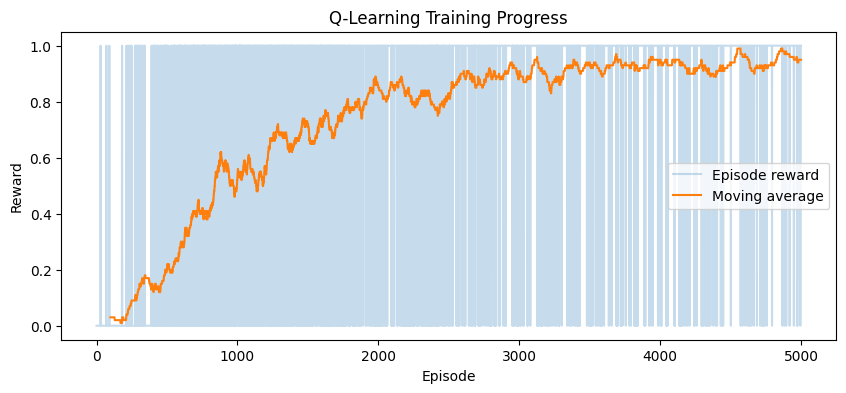

In [17]:
window = 100
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.25, label="Episode reward")
plt.plot(
    range(window - 1, len(episode_rewards)),
    moving_average,
    label="Moving average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning Training Progress")
plt.legend()
plt.show()


## 18. Visualize Epsilon Decay

Epsilon determines how much the agent explores.

At the beginning of training, epsilon is high.

As training progresses, epsilon decreases and the agent increasingly uses its learned Q-values.


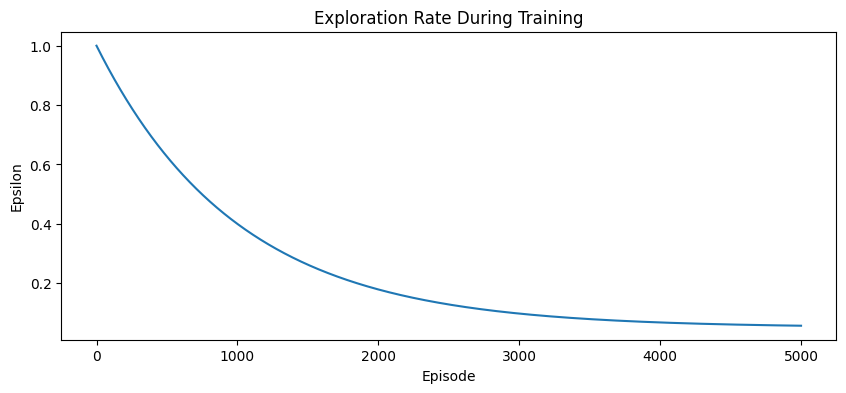

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(epsilon_history)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Exploration Rate During Training")
plt.show()


## 19. Visualize the Q-Table

A heatmap makes it easier to inspect the relative Q-values of the available actions.

Rows correspond to states and columns correspond to actions.


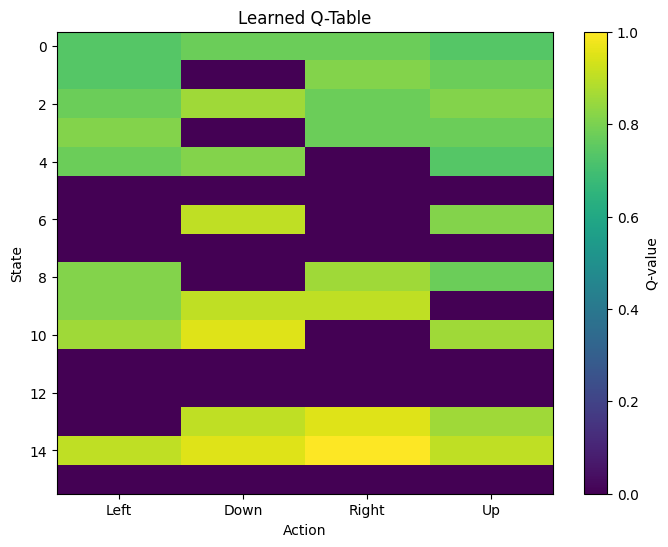

In [19]:
plt.figure(figsize=(8, 6))
plt.imshow(Q_table, aspect="auto")
plt.colorbar(label="Q-value")
plt.xticks(range(action_space), [action_names[i] for i in range(action_space)])
plt.xlabel("Action")
plt.ylabel("State")
plt.title("Learned Q-Table")
plt.show()


The heatmap shows the Q-values learned for each state-action pair. Brighter cells indicate higher Q-values and therefore more preferred actions, while darker cells indicate lower values. For each state, the action with the highest Q-value represents the action selected by the learned policy.

## 20. Animate the Trained Agent

The following section creates an **animated visualization** of the trained Q-Learning agent.

The animation shows:

- **Agent position** moving through the grid
- **Frozen cells**
- **Holes**
- **Goal**
- The **action selected at each step**
- The **current state**
- The **reward received**
- The final outcome of the episode

This is a visualization of the **learned greedy policy**. The agent selects the action with the highest Q-value at each state.

> **Note:** We use a separate environment with `render_mode="rgb_array"` for visualization. This does not change the Q-Learning algorithm or the learned Q-table.


In [20]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# Create a visualization environment.
animation_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="rgb_array"
)

def collect_episode_frames(env, Q_table, max_steps=100, seed=10):
    state, info = env.reset(seed=seed)

    frames = [env.render()]
    states = [state]
    actions = []
    rewards = []

    for step in range(max_steps):
        action = greedy_policy(Q_table, state)

        next_state, reward, terminated, truncated, info = env.step(action)

        frames.append(env.render())
        actions.append(action)
        rewards.append(reward)
        states.append(next_state)

        state = next_state

        if terminated or truncated:
            break

    return frames, states, actions, rewards

frames, states, actions, rewards = collect_episode_frames(
    animation_env,
    Q_table,
    max_steps=max_steps,
    seed=10
)

print("Number of frames:", len(frames))
print("States:", states)
print("Actions:", [action_names[a] for a in actions])
print("Rewards:", rewards)
print("Total reward:", sum(rewards))


/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Number of frames: 7
States: [0, 4, 8, 9, 13, 14, 15]
Actions: ['Down', 'Down', 'Right', 'Down', 'Right', 'Right']
Rewards: [0, 0, 0, 0, 0, 1]
Total reward: 1


### Animated Episode

Run the next cell to display the trained agent moving through FrozenLake.

The action shown in the title is the action taken **to reach the current frame**.


In [21]:
fig, ax = plt.subplots(figsize=(6, 6))

image = ax.imshow(frames[0])
ax.axis("off")

title = ax.set_title(
    f"Step 0 | State: {states[0]} | Start",
    fontsize=13,
    pad=12
)

def update(frame_number):
    image.set_data(frames[frame_number])

    if frame_number == 0:
        title.set_text(
            f"Step 0 | State: {states[0]} | Start"
        )
    else:
        action = actions[frame_number - 1]
        reward = rewards[frame_number - 1]

        if frame_number == len(frames) - 1:
            if reward == 1:
                status = "GOAL REACHED"
            else:
                status = "EPISODE ENDED"
        else:
            status = "Moving"

        title.set_text(
            f"Step {frame_number} | State: {states[frame_number]} | "
            f"Action: {action_names[action]} | Reward: {reward} | {status}"
        )

    return image, title

animation = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000,
    repeat=True
)

plt.close(fig)

# JavaScript animation works directly inside Google Colab/Jupyter.
display(HTML(animation.to_jshtml()))


### Action Legend

| Action Number | Action |
|---:|---|
| 0 | Left |
| 1 | Down |
| 2 | Right |
| 3 | Up |

The board itself shows the **agent, holes, frozen cells, and goal**. The animation title additionally reports the state, selected action, and reward at each step.


## 21. Learner Activity 6 – Experiment with Hyperparameters

Change **one parameter at a time** and repeat training.

Try:

1. Learning rate = 0.2
2. Learning rate = 0.9
3. Discount factor = 0.5
4. Discount factor = 0.99
5. Minimum epsilon = 0.01
6. Minimum epsilon = 0.20
7. Number of training episodes = 1000

For each experiment, record:

- mean evaluation reward
- standard deviation
- training behaviour
- whether the learned policy changes

### Question

Which parameter changes the learning behaviour most noticeably in your experiment?


## 22. Learner Activity 7 – Make FrozenLake Slippery

So far, `is_slippery=False` was used.

Now create another environment using:

```python
is_slippery=True
```

Train a new Q-Learning agent and compare it with the non-slippery version.

Consider:

- Does the agent receive the goal reward consistently?
- Does the learned policy change?
- Why is the problem more difficult?
- Does increasing the number of training episodes help?


In [ ]:
# TODO: Create a slippery FrozenLake environment
# slippery_env = gym.make(
#     "FrozenLake-v1",
#     map_name="4x4",
#     is_slippery=True
# )


## 23. Concept Check

Answer the following questions before finishing the lab.

1. What is meant by model-free reinforcement learning?
2. What does a row of the Q-table represent?
3. What does a column of the Q-table represent?
4. Why are Q-values initialized?
5. What is exploration?
6. What is exploitation?
7. What is the purpose of epsilon?
8. Why is epsilon reduced during training?
9. What is the role of the learning rate?
10. What is the role of the discount factor?
11. Why is the maximum next-state Q-value used in Q-Learning?
12. Why is the learned policy obtained using `argmax`?
13. What happens if the agent never explores?
14. What happens if the agent explores too much?
15. How does a slippery environment affect learning?


## 24. Summary

In this notebook, you implemented **Q-Learning** for a discrete-state, discrete-action environment.

The complete learning workflow was:

**Environment → State → Action → Reward and Next State → Q-value Update → Repeated Interaction → Learned Policy**

Key ideas:

- Q-Learning is a **model-free** reinforcement learning algorithm.
- The Q-table stores the estimated value of state-action pairs.
- Epsilon-greedy policy balances exploration and exploitation.
- The Q-value is updated using immediate reward and estimated future value.
- After training, a greedy policy can be used for evaluation.
- Hyperparameters such as learning rate, discount factor and epsilon influence learning behaviour.


## 25. Extension Task – Q-Learning for a New Grid World

Create a small custom grid-world problem.

Your environment should contain:

- a starting state,
- at least one obstacle or penalty state,
- a goal state,
- at least two possible actions.

Implement:

1. state representation,
2. action selection,
3. reward assignment,
4. Q-table initialization,
5. Q-Learning training,
6. greedy evaluation.

### Expected Outcome

The agent should gradually learn a policy that increases the expected cumulative reward.


## Lab Submission Checklist

Before submission, verify that you have:

- [ ] Executed all setup cells.
- [ ] Inspected the state and action spaces.
- [ ] Created the Q-table.
- [ ] Implemented the epsilon-greedy policy.
- [ ] Understood the Q-Learning update.
- [ ] Trained the agent.
- [ ] Evaluated the learned policy.
- [ ] Plotted training progress.
- [ ] Visualized the Q-table.
- [ ] Completed at least one hyperparameter experiment.
- [ ] Compared non-slippery and slippery FrozenLake.
- [ ] Answered the concept-check questions.
